In [ ]:
!pip install -q pandas numpy matplotlib seaborn scikit-learn

In [2]:
# ============================================
# Student Academic Performance Prediction Project
# Objective: End-to-end Machine Learning Pipeline
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report, 
                             roc_auc_score, roc_curve, mean_squared_error, 
                             mean_absolute_error, r2_score)
import warnings
warnings.filterwarnings('ignore')

# Set plotting style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

# Student Academic Performance Prediction

**Project Aim**: This project aims to develop a machine learning model to predict student academic success (pass/fail) based on various demographic and academic factors. The model will help educational institutions identify at-risk students early and implement intervention strategies.

**Dataset**: The dataset contains student performance data with features including gender, race/ethnicity, parental education level, lunch type, test preparation course, and scores in math, reading, and writing.

**Tools & Libraries Used**:
- Python: 3.13.5 Version
- Pandas: Data manipulation and analysis
- NumPy: Numerical computations
- Matplotlib & Seaborn: Data visualization
- Scikit-learn: Machine learning algorithms
- Jupyter Notebook: Development environment

In [3]:
# ============================================
# 2. DATA CLEANING & INSPECTION
# ============================================

print("="*60)
print("STEP 1: IMPORTING AND INITIAL DATA INSPECTION")
print("="*60)

# Load the dataset
df = pd.read_csv('dataset/dataset.csv')
print("✓ Dataset loaded successfully!")
print(f"✓ Dataset Shape: {df.shape}")
print(f"✓ Number of Rows: {df.shape[0]}")
print(f"✓ Number of Columns: {df.shape[1]}")

# Display first 5 rows
print("\nFirst 5 rows of the dataset:")
display(df.head())

# Display basic information
print("\nDataset Information:")
print(df.info())

# Display column names
print("\nColumn Names:")
print(df.columns.tolist())

STEP 1: IMPORTING AND INITIAL DATA INSPECTION
✓ Dataset loaded successfully!
✓ Dataset Shape: (1000, 8)
✓ Number of Rows: 1000
✓ Number of Columns: 8

First 5 rows of the dataset:


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB
None

Column Names:
['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course', 'math score', 'reading score', 'writing score']


In [4]:
print("\n" + "="*60)
print("STEP 2: DATA CLEANING")
print("="*60)

# Clean column names (remove any whitespace)
df.columns = df.columns.str.strip()
print("✓ Column names cleaned")

# Check for missing values
print("\nMissing Values Analysis:")
missing_data = df.isnull().sum()
missing_percentage = (missing_data / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Values': missing_data,
    'Percentage': missing_percentage
})
display(missing_df)

# Check for duplicate rows
duplicates = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicates}")

if duplicates > 0:
    df = df.drop_duplicates()
    print(f"✓ Duplicates removed. New shape: {df.shape}")
else:
    print("✓ No duplicates found in the dataset.")


STEP 2: DATA CLEANING
✓ Column names cleaned

Missing Values Analysis:


,Missing Values,Percentage
gender,0,0.0
race/ethnicity,0,0.0
parental level of education,0,0.0
lunch,0,0.0
test preparation course,0,0.0
math score,0,0.0
reading score,0,0.0
writing score,0,0.0



Number of duplicate rows: 0
✓ No duplicates found in the dataset.


In [5]:
print("\n" + "="*60)
print("STEP 3: DATASET DESCRIPTION")
print("="*60)

# Create target variable (Pass/Fail)
# Assuming pass if average score >= 60
df['average_score'] = (df['math score'] + df['reading score'] + df['writing score']) / 3
df['pass_fail'] = df['average_score'].apply(lambda x: 'Pass' if x >= 60 else 'Fail')

print("Dataset Overview:")
print(f"• Total Students: {len(df)}")
print(f"• Pass Count: {(df['pass_fail'] == 'Pass').sum()}")
print(f"• Fail Count: {(df['pass_fail'] == 'Fail').sum()}")
print(f"• Pass Rate: {((df['pass_fail'] == 'Pass').sum()/len(df)*100):.2f}%")

# Statistical summary for numerical columns
print("\nStatistical Summary (Numerical Columns):")
display(df[['math score', 'reading score', 'writing score', 'average_score']].describe())

print("\nStatistical Summary (Categorical Columns):")
display(df.describe(include=['object']))

# Display unique values for categorical columns
print("\nUnique Values in Categorical Columns:")
for col in df.select_dtypes(include=['object']).columns:
    if col != 'pass_fail':  # Exclude the target variable
        unique_vals = df[col].nunique()
        print(f"{col}: {unique_vals} unique values")


STEP 3: DATASET DESCRIPTION
Dataset Overview:
• Total Students: 1000
• Pass Count: 715
• Fail Count: 285
• Pass Rate: 71.50%

Statistical Summary (Numerical Columns):


,math score,reading score,writing score,average_score
count,1000.00000,1000.000000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000,67.770667
std,15.16308,14.600192,15.195657,14.257326
min,0.00000,17.000000,10.000000,9.000000
25%,57.00000,59.000000,57.750000,58.333333
50%,66.00000,70.000000,69.000000,68.333333
75%,77.00000,79.000000,79.000000,77.666667
max,100.00000,100.000000,100.000000,100.000000



Statistical Summary (Categorical Columns):


,gender,race/ethnicity,parental level of education,lunch,test preparation course,pass_fail
count,1000,1000,1000,1000,1000,1000
unique,2,5,6,2,2,2
top,female,group C,some college,standard,none,Pass
freq,518,319,226,645,642,715



Unique Values in Categorical Columns:
gender: 2 unique values
race/ethnicity: 5 unique values
parental level of education: 6 unique values
lunch: 2 unique values
test preparation course: 2 unique values


STEP 4: EXPLORATORY DATA ANALYSIS


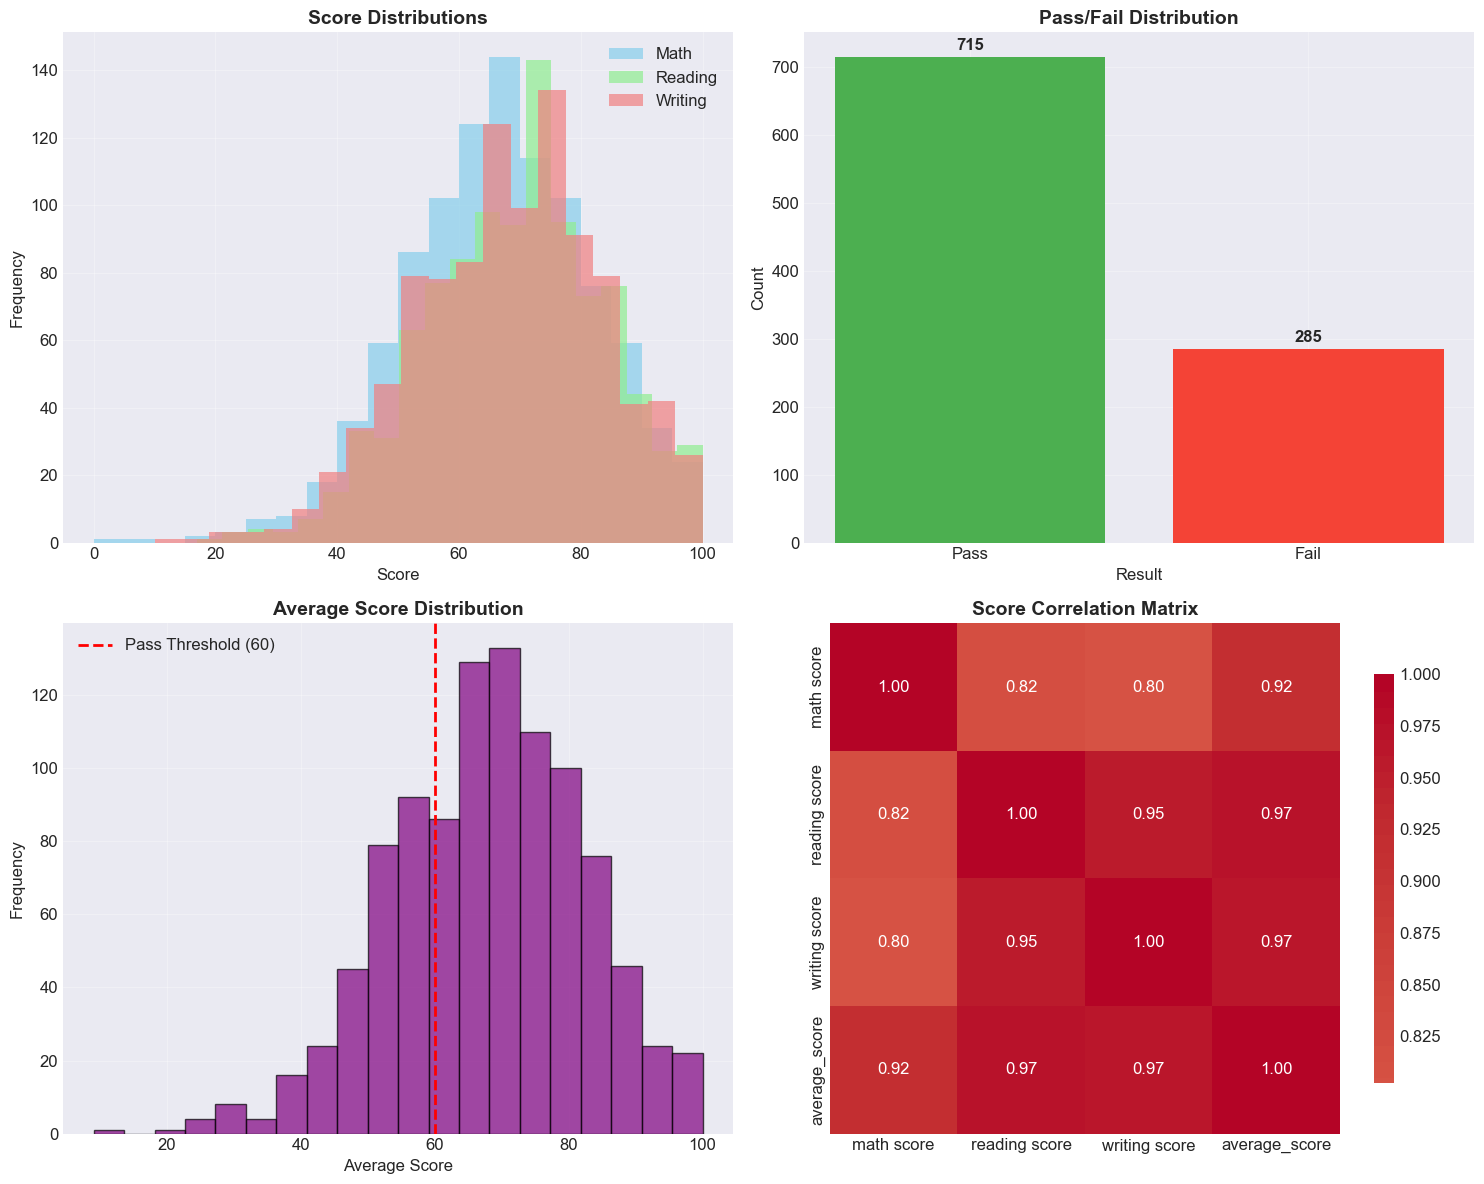

In [6]:
# ============================================
# 3. EXPLORATORY DATA ANALYSIS (EDA)
# ============================================

print("="*60)
print("STEP 4: EXPLORATORY DATA ANALYSIS")
print("="*60)

# Create a figure for distribution plots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Score Distributions
axes[0, 0].hist(df['math score'], bins=20, alpha=0.7, label='Math', color='skyblue')
axes[0, 0].hist(df['reading score'], bins=20, alpha=0.7, label='Reading', color='lightgreen')
axes[0, 0].hist(df['writing score'], bins=20, alpha=0.7, label='Writing', color='lightcoral')
axes[0, 0].set_title('Score Distributions', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Score')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Pass/Fail Distribution
pass_fail_counts = df['pass_fail'].value_counts()
colors = ['#4CAF50', '#F44336']
axes[0, 1].bar(pass_fail_counts.index, pass_fail_counts.values, color=colors)
axes[0, 1].set_title('Pass/Fail Distribution', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Result')
axes[0, 1].set_ylabel('Count')
for i, v in enumerate(pass_fail_counts.values):
    axes[0, 1].text(i, v + 10, str(v), ha='center', fontweight='bold', fontsize=12)
axes[0, 1].grid(True, alpha=0.3)

# 3. Average Score Distribution
axes[1, 0].hist(df['average_score'], bins=20, color='purple', alpha=0.7, edgecolor='black')
axes[1, 0].axvline(x=60, color='red', linestyle='--', linewidth=2, label='Pass Threshold (60)')
axes[1, 0].set_title('Average Score Distribution', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Average Score')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Correlation Heatmap
correlation_matrix = df[['math score', 'reading score', 'writing score', 'average_score']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, ax=axes[1, 1], fmt='.2f', cbar_kws={"shrink": 0.8})
axes[1, 1].set_title('Score Correlation Matrix', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

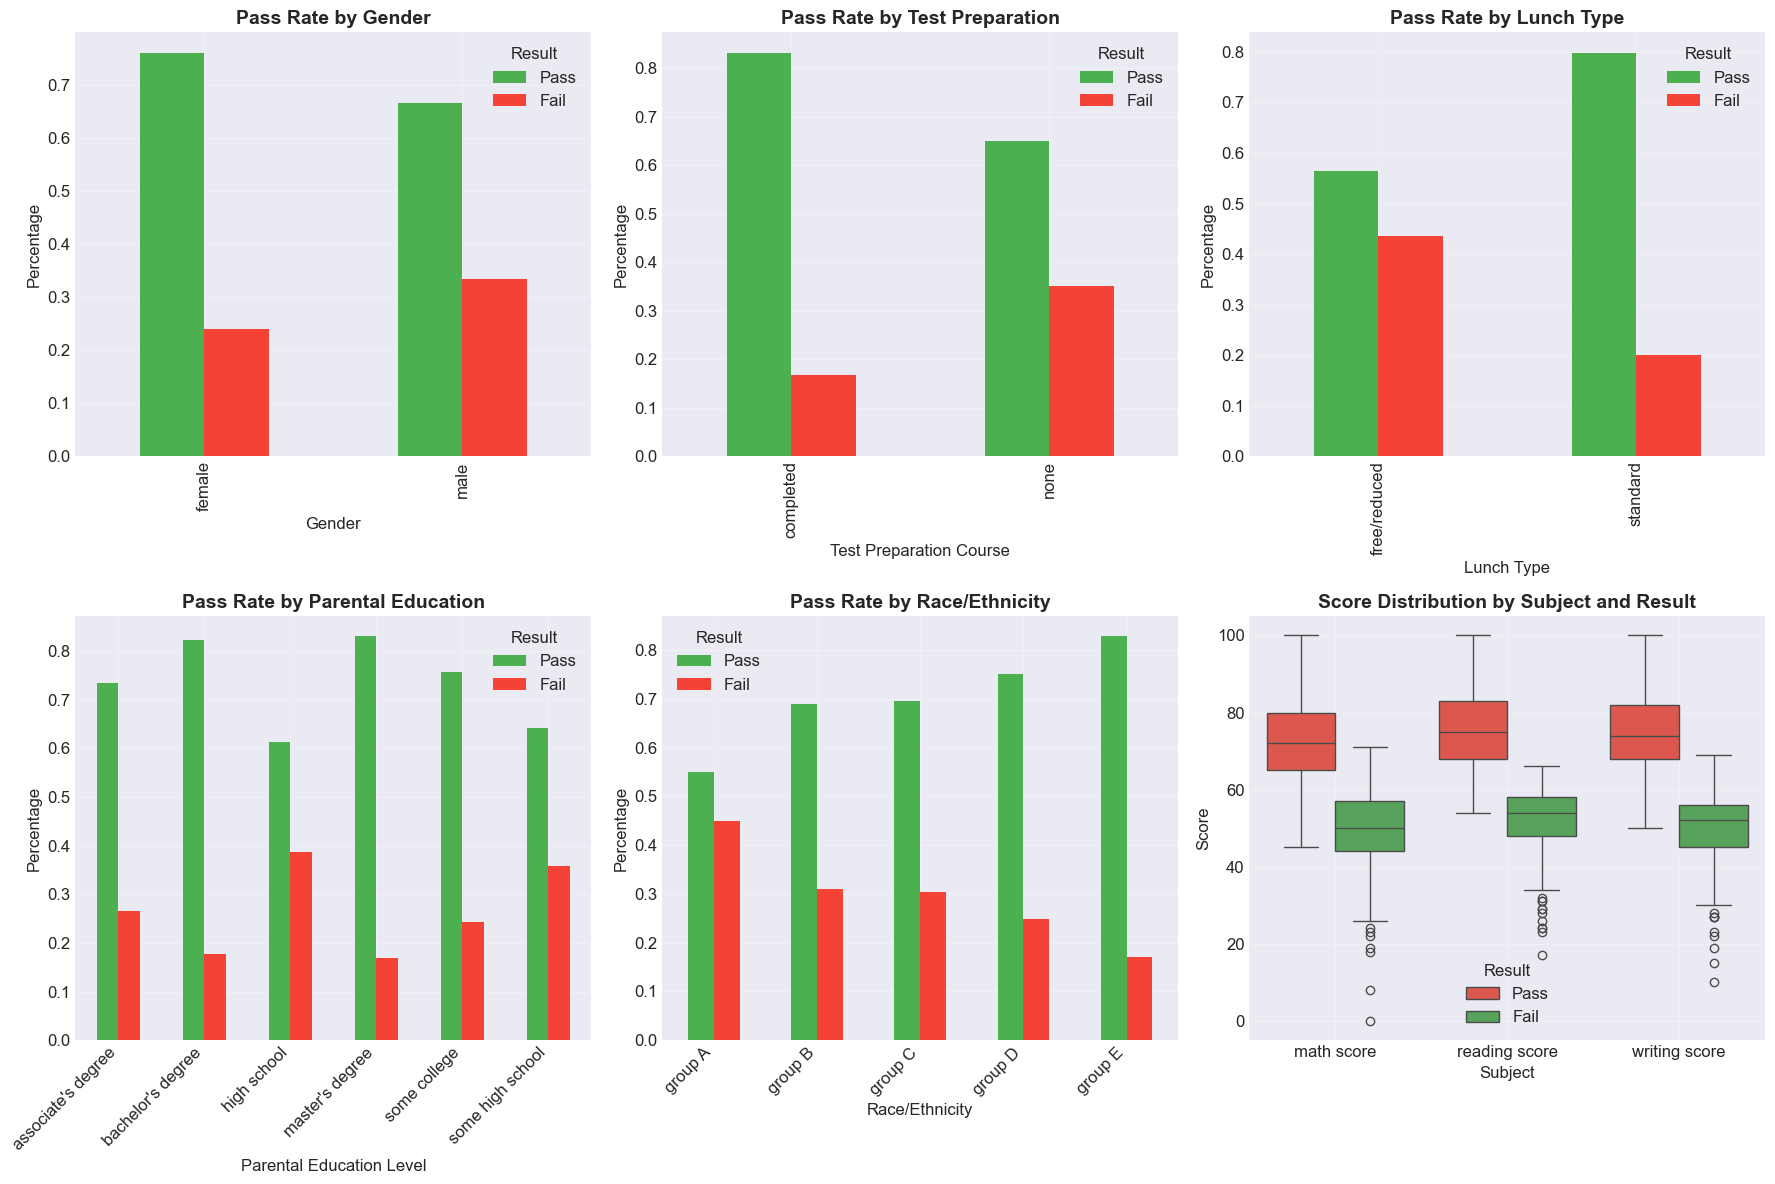

In [7]:
# Create another figure for categorical analysis
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Pass Rate by Gender
gender_pass = df.groupby('gender')['pass_fail'].value_counts(normalize=True).unstack()
gender_pass[['Pass', 'Fail']].plot(kind='bar', ax=axes[0, 0], color=['#4CAF50', '#F44336'])
axes[0, 0].set_title('Pass Rate by Gender', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Gender')
axes[0, 0].set_ylabel('Percentage')
axes[0, 0].legend(title='Result')
axes[0, 0].grid(True, alpha=0.3)

# 2. Pass Rate by Test Preparation
test_prep_pass = df.groupby('test preparation course')['pass_fail'].value_counts(normalize=True).unstack()
test_prep_pass[['Pass', 'Fail']].plot(kind='bar', ax=axes[0, 1], color=['#4CAF50', '#F44336'])
axes[0, 1].set_title('Pass Rate by Test Preparation', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Test Preparation Course')
axes[0, 1].set_ylabel('Percentage')
axes[0, 1].legend(title='Result')
axes[0, 1].grid(True, alpha=0.3)

# 3. Pass Rate by Lunch Type
lunch_pass = df.groupby('lunch')['pass_fail'].value_counts(normalize=True).unstack()
lunch_pass[['Pass', 'Fail']].plot(kind='bar', ax=axes[0, 2], color=['#4CAF50', '#F44336'])
axes[0, 2].set_title('Pass Rate by Lunch Type', fontsize=14, fontweight='bold')
axes[0, 2].set_xlabel('Lunch Type')
axes[0, 2].set_ylabel('Percentage')
axes[0, 2].legend(title='Result')
axes[0, 2].grid(True, alpha=0.3)

# 4. Pass Rate by Parental Education
parent_edu_pass = df.groupby('parental level of education')['pass_fail'].value_counts(normalize=True).unstack()
parent_edu_pass[['Pass', 'Fail']].plot(kind='bar', ax=axes[1, 0], color=['#4CAF50', '#F44336'])
axes[1, 0].set_title('Pass Rate by Parental Education', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Parental Education Level')
axes[1, 0].set_ylabel('Percentage')
axes[1, 0].legend(title='Result')
plt.setp(axes[1, 0].xaxis.get_majorticklabels(), rotation=45, ha='right')
axes[1, 0].grid(True, alpha=0.3)

# 5. Pass Rate by Race/Ethnicity
race_pass = df.groupby('race/ethnicity')['pass_fail'].value_counts(normalize=True).unstack()
race_pass[['Pass', 'Fail']].plot(kind='bar', ax=axes[1, 1], color=['#4CAF50', '#F44336'])
axes[1, 1].set_title('Pass Rate by Race/Ethnicity', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Race/Ethnicity')
axes[1, 1].set_ylabel('Percentage')
axes[1, 1].legend(title='Result')
plt.setp(axes[1, 1].xaxis.get_majorticklabels(), rotation=45, ha='right')
axes[1, 1].grid(True, alpha=0.3)

# 6. Box Plot of Scores by Pass/Fail
df_melted = df.melt(id_vars=['pass_fail'], 
                    value_vars=['math score', 'reading score', 'writing score'],
                    var_name='Subject', value_name='Score')
sns.boxplot(x='Subject', y='Score', hue='pass_fail', data=df_melted, 
            ax=axes[1, 2], palette=['#F44336', '#4CAF50'])
axes[1, 2].set_title('Score Distribution by Subject and Result', fontsize=14, fontweight='bold')
axes[1, 2].set_xlabel('Subject')
axes[1, 2].set_ylabel('Score')
axes[1, 2].legend(title='Result')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


OUTLIER DETECTION ANALYSIS
Numerical columns for outlier analysis: ['math score', 'reading score', 'writing score']

math score:
  Q1: 57.00, Q3: 77.00, IQR: 20.00
  Lower bound: 27.00, Upper bound: 107.00
  Number of outliers: 8 (0.8%)

reading score:
  Q1: 59.00, Q3: 79.00, IQR: 20.00
  Lower bound: 29.00, Upper bound: 109.00
  Number of outliers: 6 (0.6%)

writing score:
  Q1: 57.75, Q3: 79.00, IQR: 21.25
  Lower bound: 25.88, Upper bound: 110.88
  Number of outliers: 5 (0.5%)


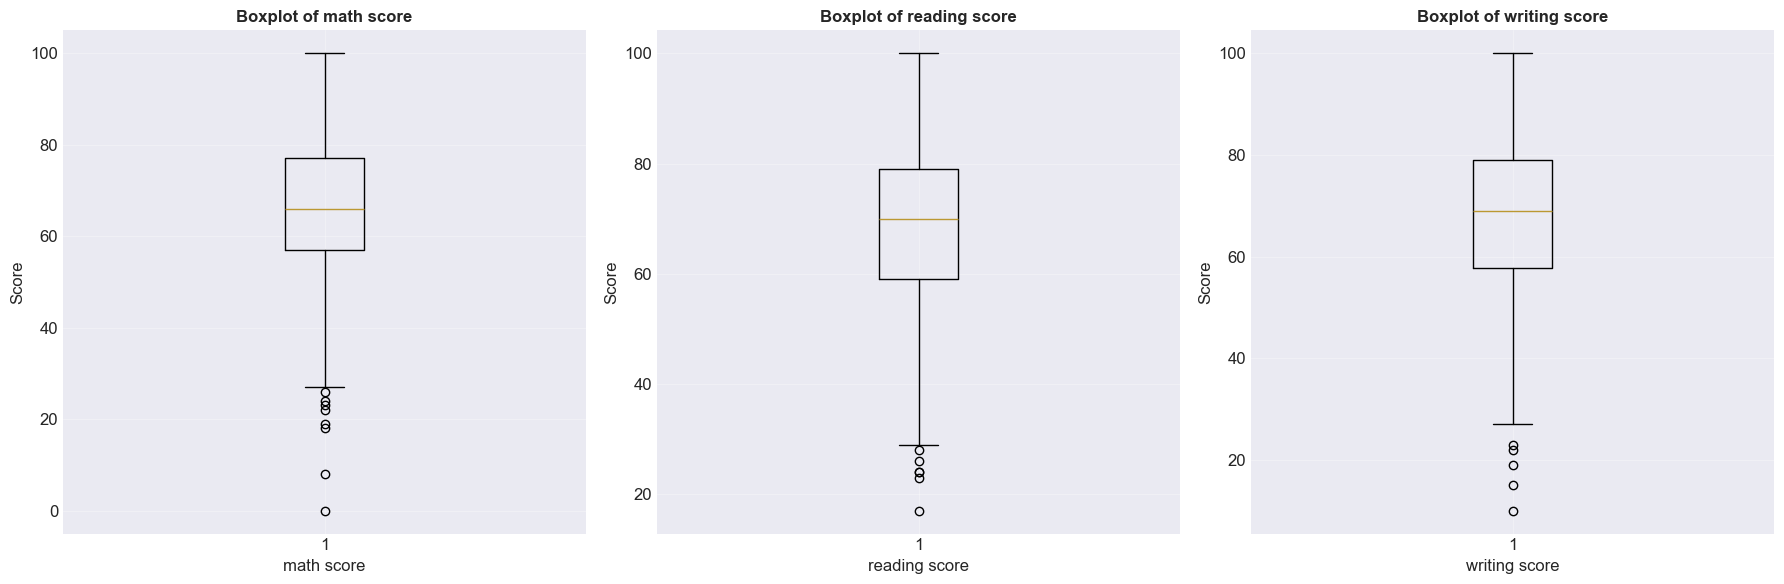

In [8]:
# ============================================
# SIMPLE OUTLIER DETECTION - NO SAVING
# ============================================

print("\n" + "="*60)
print("OUTLIER DETECTION ANALYSIS")
print("="*60)

# List of numerical columns to visualize for outliers
numerical_columns = ['math score', 'reading score', 'writing score']
print(f"Numerical columns for outlier analysis: {numerical_columns}")

# Create boxplots to visualize outliers
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, col in enumerate(numerical_columns):
    # Create boxplot
    axes[idx].boxplot(df[col].dropna())
    axes[idx].set_title(f'Boxplot of {col}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Score')
    axes[idx].grid(True, alpha=0.3)
    
    # Calculate statistics
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    # Count outliers
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"\n{col}:")
    print(f"  Q1: {q1:.2f}, Q3: {q3:.2f}, IQR: {iqr:.2f}")
    print(f"  Lower bound: {lower_bound:.2f}, Upper bound: {upper_bound:.2f}")
    print(f"  Number of outliers: {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)")

plt.tight_layout()
plt.show()

In [9]:
# ============================================
# 4. DATA PREPARATION
# ============================================

print("="*60)
print("STEP 5: DATA PREPARATION")
print("="*60)

# Create a copy for feature engineering
df_processed = df.copy()

print("\n1. Feature Engineering:")
print("-" * 40)

# Create total score feature
df_processed['total_score'] = df_processed['math score'] + df_processed['reading score'] + df_processed['writing score']

# Create score variation feature (standard deviation of three scores)
df_processed['score_variation'] = df_processed[['math score', 'reading score', 'writing score']].std(axis=1)

# Create performance categories
def get_performance_category(avg_score):
    if avg_score >= 85:
        return 'Excellent'
    elif avg_score >= 70:
        return 'Good'
    elif avg_score >= 60:
        return 'Average'
    elif avg_score >= 50:
        return 'Below Average'
    else:
        return 'Poor'

df_processed['performance_category'] = df_processed['average_score'].apply(get_performance_category)

# Create binary features
df_processed['has_test_prep'] = df_processed['test preparation course'].apply(lambda x: 1 if x == 'completed' else 0)
df_processed['has_standard_lunch'] = df_processed['lunch'].apply(lambda x: 1 if x == 'standard' else 0)

print("✓ New features created:")
print(f"  - total_score: Sum of all scores")
print(f"  - score_variation: Standard deviation of scores")
print(f"  - performance_category: Performance level based on average score")
print(f"  - has_test_prep: Binary indicator for test preparation")
print(f"  - has_standard_lunch: Binary indicator for lunch type")

# Display new features
print("\nNew Features Sample:")
display(df_processed[['total_score', 'score_variation', 'performance_category', 
                      'has_test_prep', 'has_standard_lunch']].head())

STEP 5: DATA PREPARATION

1. Feature Engineering:
----------------------------------------
✓ New features created:
  - total_score: Sum of all scores
  - score_variation: Standard deviation of scores
  - performance_category: Performance level based on average score
  - has_test_prep: Binary indicator for test preparation
  - has_standard_lunch: Binary indicator for lunch type

New Features Sample:


,total_score,score_variation,performance_category,has_test_prep,has_standard_lunch
0,218,1.154701,Good,0,1
1,247,11.590226,Good,1,1
2,278,2.516611,Excellent,0,1
3,148,6.806859,Poor,0,0
4,229,1.527525,Good,0,1


In [10]:
print("\n2. Feature Selection and Encoding:")
print("-" * 40)

# Select features for the model
categorical_features = ['gender', 'race/ethnicity', 'parental level of education',
                       'performance_category']
numerical_features = ['math score', 'reading score', 'writing score',
                     'total_score', 'score_variation', 'has_test_prep', 'has_standard_lunch']

# Create feature DataFrame
X = df_processed[categorical_features + numerical_features].copy()
y = df_processed['pass_fail'].copy()

print(f"✓ Selected {len(categorical_features)} categorical features")
print(f"✓ Selected {len(numerical_features)} numerical features")
print(f"✓ Total features: {X.shape[1]}")
print(f"✓ Target variable shape: {y.shape}")

# Encode categorical variables
X_encoded = X.copy()
label_encoders = {}

for col in categorical_features:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X[col])
    label_encoders[col] = le
    print(f"  - Encoded '{col}' with {len(le.classes_)} unique values")

print("\n✓ Sample of Encoded Data:")
display(X_encoded.head())


2. Feature Selection and Encoding:
----------------------------------------
✓ Selected 4 categorical features
✓ Selected 7 numerical features
✓ Total features: 11
✓ Target variable shape: (1000,)
  - Encoded 'gender' with 2 unique values
  - Encoded 'race/ethnicity' with 5 unique values
  - Encoded 'parental level of education' with 6 unique values
  - Encoded 'performance_category' with 5 unique values

✓ Sample of Encoded Data:


,gender,race/ethnicity,parental level of education,performance_category,math score,reading score,writing score,total_score,score_variation,has_test_prep,has_standard_lunch
0,0,1,1,3,72,72,74,218,1.154701,0,1
1,0,2,4,3,69,90,88,247,11.590226,1,1
2,0,1,3,2,90,95,93,278,2.516611,0,1
3,1,0,0,4,47,57,44,148,6.806859,0,0
4,1,2,4,3,76,78,75,229,1.527525,0,1


In [11]:
print("\n3. Data Splitting and Scaling:")
print("-" * 40)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print(f"✓ Training set size: {X_train.shape[0]} samples ({(X_train.shape[0]/len(X)*100):.1f}%)")
print(f"✓ Testing set size: {X_test.shape[0]} samples ({(X_test.shape[0]/len(X)*100):.1f}%)")
print(f"✓ Features per sample: {X_train.shape[1]}")

# Check class distribution
print("\nClass Distribution:")
print("  Training set:")
train_pass = (y_train == 'Pass').sum()
train_fail = (y_train == 'Fail').sum()
print(f"    Pass: {train_pass} ({(train_pass/len(y_train)*100):.1f}%)")
print(f"    Fail: {train_fail} ({(train_fail/len(y_train)*100):.1f}%)")

print("\n  Testing set:")
test_pass = (y_test == 'Pass').sum()
test_fail = (y_test == 'Fail').sum()
print(f"    Pass: {test_pass} ({(test_pass/len(y_test)*100):.1f}%)")
print(f"    Fail: {test_fail} ({(test_fail/len(y_test)*100):.1f}%)")

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n✓ Features scaled using StandardScaler")
print(f"✓ Training data shape after scaling: {X_train_scaled.shape}")
print(f"✓ Testing data shape after scaling: {X_test_scaled.shape}")


3. Data Splitting and Scaling:
----------------------------------------
✓ Training set size: 800 samples (80.0%)
✓ Testing set size: 200 samples (20.0%)
✓ Features per sample: 11

Class Distribution:
  Training set:
    Pass: 572 (71.5%)
    Fail: 228 (28.5%)

  Testing set:
    Pass: 143 (71.5%)
    Fail: 57 (28.5%)

✓ Features scaled using StandardScaler
✓ Training data shape after scaling: (800, 11)
✓ Testing data shape after scaling: (200, 11)


In [12]:
# ============================================
# 5. TRAINING MODEL
# ============================================

print("="*60)
print("STEP 6: MODEL TRAINING")
print("="*60)

# Initialize models with default parameters
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=5),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100, max_depth=5),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42, n_estimators=100),
    'Support Vector Machine': SVC(random_state=42, probability=True)
}

# Dictionary to store training results
training_results = {}

print("Training multiple models for comparison:\n")
print("-" * 60)

STEP 6: MODEL TRAINING
Training multiple models for comparison:

------------------------------------------------------------


In [13]:
# Train each model and store results
for model_name, model in models.items():
    print(f"Training {model_name}...")
    
    # Train the model
    model.fit(X_train_scaled, y_train)
    
    # Make predictions on training set
    y_train_pred = model.predict(X_train_scaled)
    
    # Calculate training metrics
    train_accuracy = accuracy_score(y_train, y_train_pred)
    train_precision = precision_score(y_train, y_train_pred, pos_label='Pass')
    train_recall = recall_score(y_train, y_train_pred, pos_label='Pass')
    train_f1 = f1_score(y_train, y_train_pred, pos_label='Pass')
    
    # Store results
    training_results[model_name] = {
        'model': model,
        'train_accuracy': train_accuracy,
        'train_precision': train_precision,
        'train_recall': train_recall,
        'train_f1': train_f1
    }
    
    print(f"  ✓ Training Accuracy:  {train_accuracy:.4f}")
    print(f"  ✓ Training Precision: {train_precision:.4f}")
    print(f"  ✓ Training Recall:    {train_recall:.4f}")
    print(f"  ✓ Training F1-Score:  {train_f1:.4f}")
    print("-" * 40)

Training Logistic Regression...
  ✓ Training Accuracy:  1.0000
  ✓ Training Precision: 1.0000
  ✓ Training Recall:    1.0000
  ✓ Training F1-Score:  1.0000
----------------------------------------
Training Decision Tree...
  ✓ Training Accuracy:  1.0000
  ✓ Training Precision: 1.0000
  ✓ Training Recall:    1.0000
  ✓ Training F1-Score:  1.0000
----------------------------------------
Training Random Forest...


  ✓ Training Accuracy:  1.0000
  ✓ Training Precision: 1.0000
  ✓ Training Recall:    1.0000
  ✓ Training F1-Score:  1.0000
----------------------------------------
Training Gradient Boosting...
  ✓ Training Accuracy:  1.0000
  ✓ Training Precision: 1.0000
  ✓ Training Recall:    1.0000
  ✓ Training F1-Score:  1.0000
----------------------------------------
Training Support Vector Machine...
  ✓ Training Accuracy:  0.9988
  ✓ Training Precision: 0.9983
  ✓ Training Recall:    1.0000
  ✓ Training F1-Score:  0.9991
----------------------------------------



Model Comparison (Training Performance):
------------------------------------------------------------


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,1.00000,1.000000,1.0,1.000000
1,Decision Tree,1.00000,1.000000,1.0,1.000000
2,Random Forest,1.00000,1.000000,1.0,1.000000
3,Gradient Boosting,1.00000,1.000000,1.0,1.000000
4,Support Vector Machine,0.99875,0.998255,1.0,0.999127


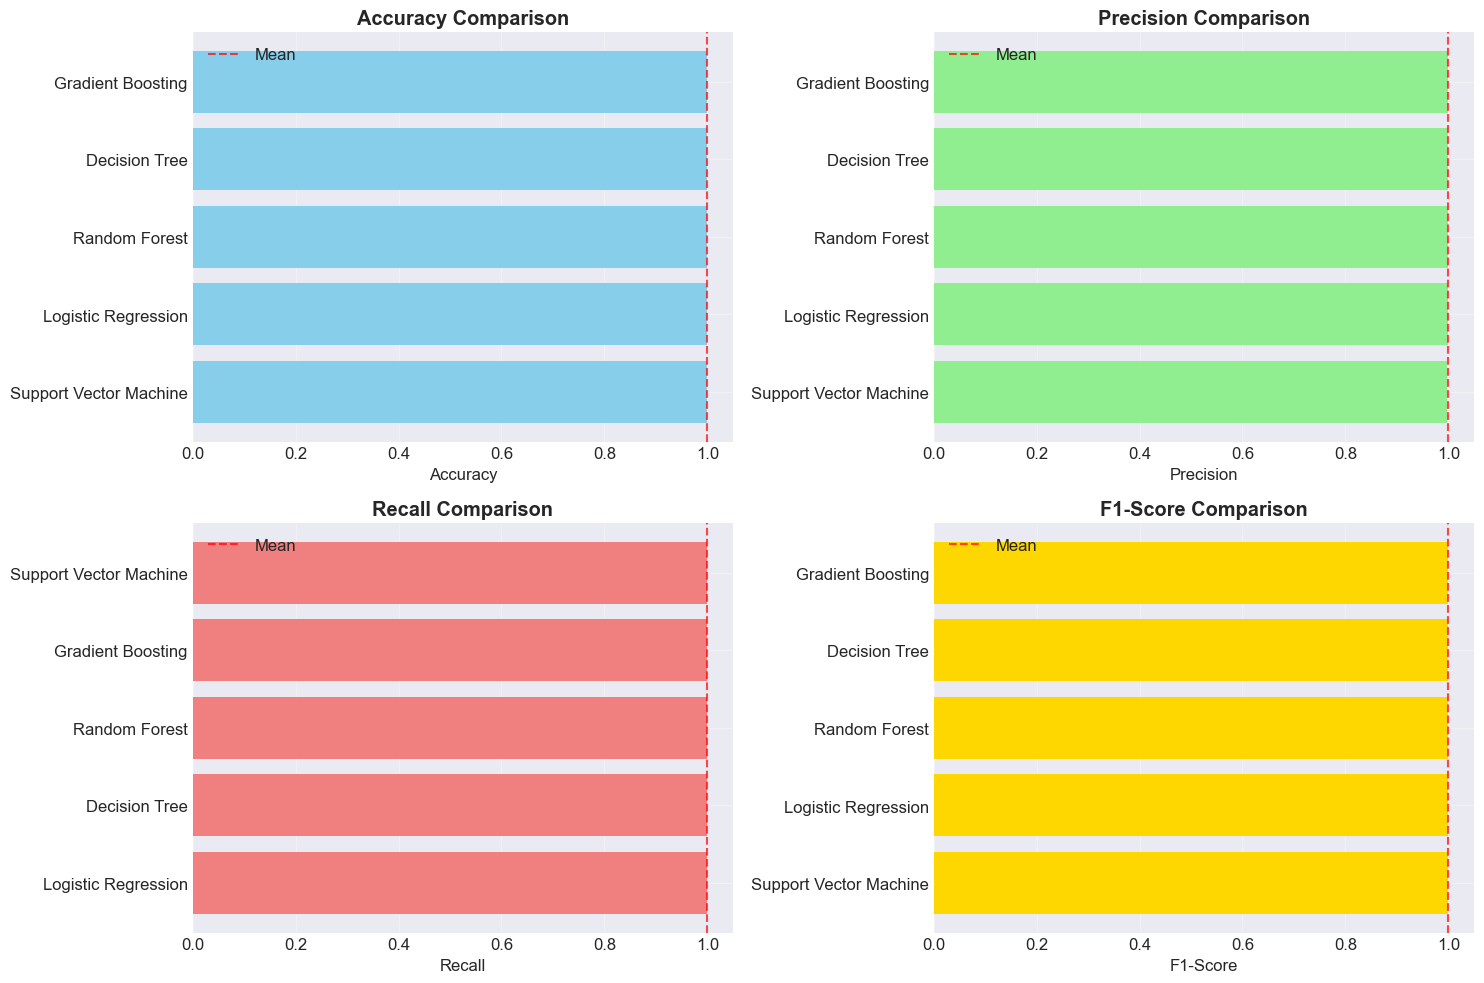


✓ Selected Best Model: Logistic Regression
  Reason: Highest F1-Score (1.0000)


In [14]:
# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Model': list(training_results.keys()),
    'Accuracy': [training_results[m]['train_accuracy'] for m in training_results.keys()],
    'Precision': [training_results[m]['train_precision'] for m in training_results.keys()],
    'Recall': [training_results[m]['train_recall'] for m in training_results.keys()],
    'F1-Score': [training_results[m]['train_f1'] for m in training_results.keys()]
})

print("\nModel Comparison (Training Performance):")
print("-" * 60)
display(comparison_df.sort_values('F1-Score', ascending=False))

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['skyblue', 'lightgreen', 'lightcoral', 'gold']

for idx, (ax, metric, color) in enumerate(zip(axes.flat, metrics, colors)):
    sorted_df = comparison_df.sort_values(metric, ascending=True)
    ax.barh(sorted_df['Model'], sorted_df[metric], color=color)
    ax.set_xlabel(metric)
    ax.set_title(f'{metric} Comparison', fontweight='bold')
    ax.axvline(x=sorted_df[metric].mean(), color='red', linestyle='--', alpha=0.7, label='Mean')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Select best model based on F1-Score
best_model_name = comparison_df.loc[comparison_df['F1-Score'].idxmax(), 'Model']
best_model = training_results[best_model_name]['model']
print(f"\n✓ Selected Best Model: {best_model_name}")
print(f"  Reason: Highest F1-Score ({comparison_df['F1-Score'].max():.4f})")

In [15]:
# ============================================
# 6. TESTING & EVALUATION MODEL
# ============================================

print("="*60)
print("STEP 7: MODEL TESTING & EVALUATION")
print("="*60)

# Dictionary to store test results
test_results = {}

print("Testing all models on unseen data:\n")
print("-" * 60)

# Convert labels to binary for ROC-AUC calculation
y_test_binary = (y_test == 'Pass').astype(int)

for model_name in models.keys():
    model = training_results[model_name]['model']
    
    # Make predictions on test set
    y_test_pred = model.predict(X_test_scaled)
    
    # Calculate metrics
    test_accuracy = accuracy_score(y_test, y_test_pred)
    test_precision = precision_score(y_test, y_test_pred, pos_label='Pass')
    test_recall = recall_score(y_test, y_test_pred, pos_label='Pass')
    test_f1 = f1_score(y_test, y_test_pred, pos_label='Pass')
    
    # Calculate confusion matrix
    cm = confusion_matrix(y_test, y_test_pred, labels=['Pass', 'Fail'])
    
    # Calculate ROC-AUC if probabilities are available
    try:
        if hasattr(model, 'predict_proba'):
            y_test_pred_proba = model.predict_proba(X_test_scaled)
            # For binary classification, use the probability of positive class
            if y_test_pred_proba.shape[1] == 2:
                y_test_pred_proba_binary = y_test_pred_proba[:, 1]
            else:
                # For multi-class, use OvR strategy
                from sklearn.preprocessing import label_binarize
                y_test_bin = label_binarize(y_test, classes=['Fail', 'Pass'])
                y_test_pred_proba_binary = y_test_pred_proba[:, 1] if y_test_pred_proba.shape[1] > 1 else y_test_pred_proba[:, 0]
            
            roc_auc = roc_auc_score(y_test_binary, y_test_pred_proba_binary)
        else:
            roc_auc = None
    except Exception as e:
        print(f"  Warning: Could not calculate ROC-AUC for {model_name}: {str(e)}")
        roc_auc = None
    
    # Store results
    test_results[model_name] = {
        'accuracy': test_accuracy,
        'precision': test_precision,
        'recall': test_recall,
        'f1': test_f1,
        'confusion_matrix': cm,
        'roc_auc': roc_auc
    }
    
    print(f"{model_name}:")
    print(f"  ✓ Accuracy:  {test_accuracy:.4f}")
    print(f"  ✓ Precision: {test_precision:.4f}")
    print(f"  ✓ Recall:    {test_recall:.4f}")
    print(f"  ✓ F1-Score:  {test_f1:.4f}")
    if roc_auc is not None:
        print(f"  ✓ ROC-AUC:   {roc_auc:.4f}")
    else:
        print(f"  ✓ ROC-AUC:   Not available")
    print("-" * 40)

STEP 7: MODEL TESTING & EVALUATION
Testing all models on unseen data:

------------------------------------------------------------
Logistic Regression:
  ✓ Accuracy:  1.0000
  ✓ Precision: 1.0000
  ✓ Recall:    1.0000
  ✓ F1-Score:  1.0000
  ✓ ROC-AUC:   1.0000
----------------------------------------
Decision Tree:
  ✓ Accuracy:  1.0000
  ✓ Precision: 1.0000
  ✓ Recall:    1.0000
  ✓ F1-Score:  1.0000
  ✓ ROC-AUC:   1.0000
----------------------------------------
Random Forest:
  ✓ Accuracy:  1.0000
  ✓ Precision: 1.0000
  ✓ Recall:    1.0000
  ✓ F1-Score:  1.0000
  ✓ ROC-AUC:   1.0000
----------------------------------------
Gradient Boosting:
  ✓ Accuracy:  1.0000
  ✓ Precision: 1.0000
  ✓ Recall:    1.0000
  ✓ F1-Score:  1.0000
  ✓ ROC-AUC:   1.0000
----------------------------------------
Support Vector Machine:
  ✓ Accuracy:  1.0000
  ✓ Precision: 1.0000
  ✓ Recall:    1.0000
  ✓ F1-Score:  1.0000
  ✓ ROC-AUC:   1.0000
----------------------------------------



Detailed Evaluation of Best Model (Logistic Regression):

Classification Report:
----------------------------------------
              precision    recall  f1-score   support

        Pass       1.00      1.00      1.00        57
        Fail       1.00      1.00      1.00       143

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200


Confusion Matrix:
----------------------------------------


,Predicted Pass,Predicted Fail
Actual Pass,143,0
Actual Fail,0,57


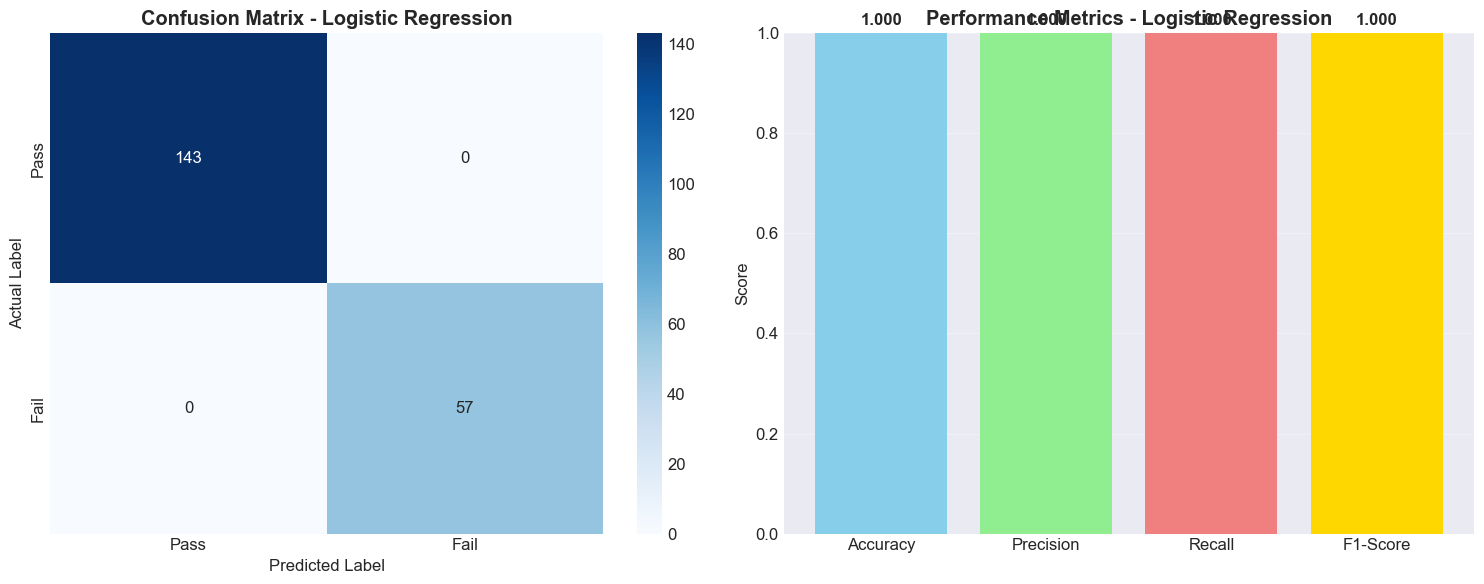

In [16]:
print(f"\nDetailed Evaluation of Best Model ({best_model_name}):")
print("="*60)

best_model_test = test_results[best_model_name]
y_test_pred_best = best_model.predict(X_test_scaled)

# Classification Report
print("\nClassification Report:")
print("-" * 40)
print(classification_report(y_test, y_test_pred_best, target_names=['Pass', 'Fail']))

# Confusion Matrix
print("\nConfusion Matrix:")
print("-" * 40)
cm = best_model_test['confusion_matrix']
cm_df = pd.DataFrame(cm, 
                     index=['Actual Pass', 'Actual Fail'], 
                     columns=['Predicted Pass', 'Predicted Fail'])
display(cm_df)

# Visualization of Confusion Matrix
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Confusion Matrix Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Pass', 'Fail'], 
            yticklabels=['Pass', 'Fail'], ax=ax1)
ax1.set_title(f'Confusion Matrix - {best_model_name}', fontweight='bold')
ax1.set_ylabel('Actual Label')
ax1.set_xlabel('Predicted Label')

# Metrics Comparison Bar Chart
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
metrics_values = [
    best_model_test['accuracy'],
    best_model_test['precision'],
    best_model_test['recall'],
    best_model_test['f1']
]

bars = ax2.bar(metrics_names, metrics_values, color=['skyblue', 'lightgreen', 'lightcoral', 'gold'])
ax2.set_title(f'Performance Metrics - {best_model_name}', fontweight='bold')
ax2.set_ylabel('Score')
ax2.set_ylim([0, 1])
ax2.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, value in zip(bars, metrics_values):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{value:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

In [17]:
print("\nFeature Importance Analysis:")
print("="*60)

if hasattr(best_model, 'feature_importances_'):
    # Get feature importances
    importances = best_model.feature_importances_
    feature_names = X.columns
    
    # Create DataFrame for feature importances
    feature_importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values('Importance', ascending=False)
    
    print("\nTop 10 Most Important Features:")
    print("-" * 40)
    display(feature_importance_df.head(10))
    
    # Visualization
    plt.figure(figsize=(12, 8))
    top_features = feature_importance_df.head(10)
    bars = plt.barh(top_features['Feature'], top_features['Importance'])
    plt.xlabel('Importance Score', fontweight='bold')
    plt.title(f'Top 10 Feature Importances - {best_model_name}', fontweight='bold')
    plt.gca().invert_yaxis()
    
    # Add value labels
    for bar in bars:
        width = bar.get_width()
        plt.text(width + 0.001, bar.get_y() + bar.get_height()/2,
                f'{width:.4f}', ha='left', va='center', fontweight='bold')
    
    plt.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()
    
    # Identify key academic risk indicators
    print("\nKey Academic Risk Indicators Identified:")
    print("-" * 40)
    risk_indicators = feature_importance_df.head(5)
    for idx, row in risk_indicators.iterrows():
        print(f"  • {row['Feature']}: Importance = {row['Importance']:.4f}")
else:
    print("Feature importances not available for this model type.")
    print("Note: Logistic Regression and SVM don't provide feature importance scores.")


Feature Importance Analysis:
Feature importances not available for this model type.
Note: Logistic Regression and SVM don't provide feature importance scores.



ROC Curve Analysis:


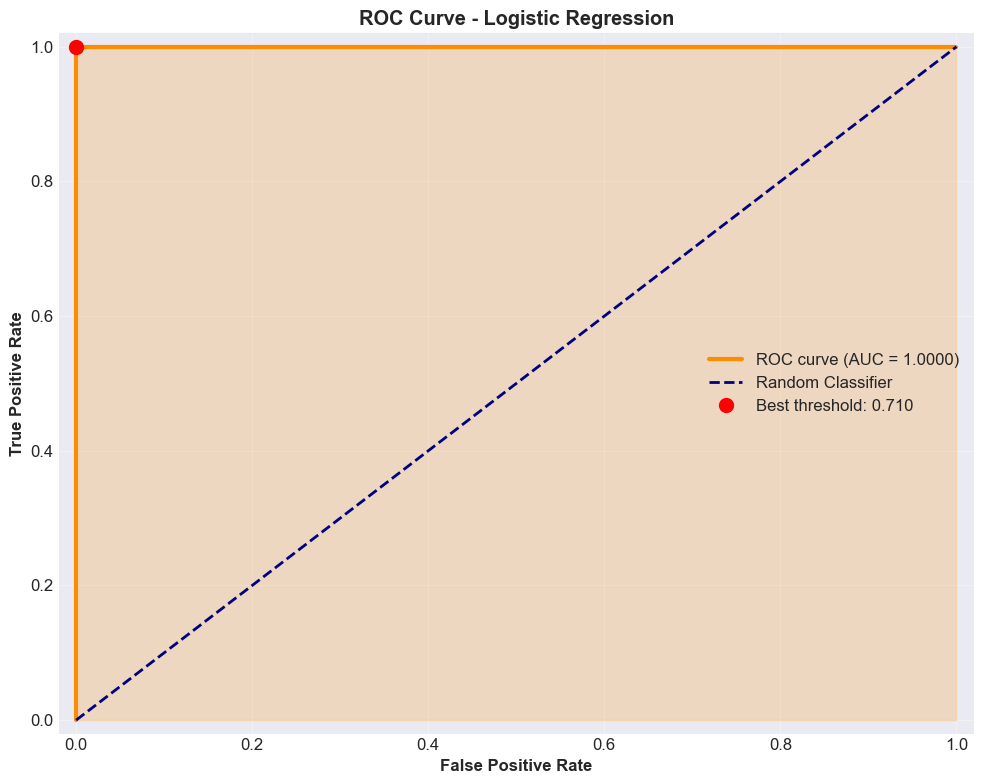

✓ ROC-AUC Score: 1.0000
✓ Best Threshold: 0.710


In [18]:
print("\nROC Curve Analysis:")
print("="*60)

# Check if best model supports probability predictions
if best_model_test['roc_auc'] is not None:
    # Get predicted probabilities
    try:
        if hasattr(best_model, 'predict_proba'):
            y_test_pred_proba = best_model.predict_proba(X_test_scaled)
            
            # Handle binary classification
            if y_test_pred_proba.shape[1] == 2:
                y_test_pred_proba_binary = y_test_pred_proba[:, 1]
            else:
                y_test_pred_proba_binary = y_test_pred_proba[:, 1] if y_test_pred_proba.shape[1] > 1 else y_test_pred_proba[:, 0]
            
            # Convert y_test to binary for ROC curve
            y_test_binary = (y_test == 'Pass').astype(int)
            
            # Calculate ROC curve
            fpr, tpr, thresholds = roc_curve(y_test_binary, y_test_pred_proba_binary)
            roc_auc = roc_auc_score(y_test_binary, y_test_pred_proba_binary)
            
            # Plot ROC curve
            plt.figure(figsize=(10, 8))
            plt.plot(fpr, tpr, color='darkorange', lw=3, 
                     label=f'ROC curve (AUC = {roc_auc:.4f})')
            plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
            plt.fill_between(fpr, tpr, alpha=0.2, color='darkorange')
            
            plt.xlim([-0.02, 1.02])
            plt.ylim([-0.02, 1.02])
            plt.xlabel('False Positive Rate', fontweight='bold')
            plt.ylabel('True Positive Rate', fontweight='bold')
            plt.title(f'ROC Curve - {best_model_name}', fontweight='bold')
            plt.legend(loc="lower right")
            plt.grid(True, alpha=0.3)
            
            # Add annotation for best threshold
            youden_idx = np.argmax(tpr - fpr)
            best_threshold = thresholds[youden_idx]
            plt.plot(fpr[youden_idx], tpr[youden_idx], 'ro', markersize=10, 
                     label=f'Best threshold: {best_threshold:.3f}')
            plt.legend()
            
            plt.tight_layout()
            plt.show()
            
            print(f"✓ ROC-AUC Score: {roc_auc:.4f}")
            print(f"✓ Best Threshold: {best_threshold:.3f}")
        else:
            print("ROC Curve not available (model doesn't provide probability estimates)")
    except Exception as e:
        print(f"✗ Error generating ROC curve: {str(e)}")
else:
    print("ROC Curve not available for this model")


Cross-Validation Analysis (5-fold):


Cross-Validation F1 Scores: [1. 1. 1. 1. 1.]
Mean CV F1 Score: 1.0000
Std CV F1 Score: 0.0000
Score Range: 1.0000 - 1.0000


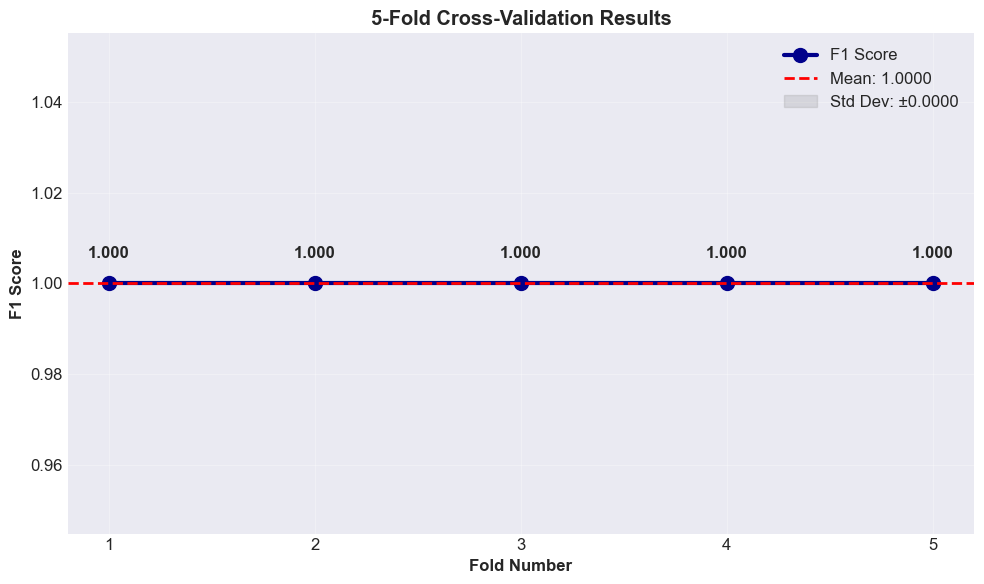


✓ Model Stability: Good (based on std: 0.0000)


In [19]:
print("\nCross-Validation Analysis (5-fold):")
print("="*60)

# Perform cross-validation on best model
cv_scores = cross_val_score(best_model, X_train_scaled, y_train, 
                           cv=5, scoring='f1_weighted')

print(f"Cross-Validation F1 Scores: {cv_scores}")
print(f"Mean CV F1 Score: {cv_scores.mean():.4f}")
print(f"Std CV F1 Score: {cv_scores.std():.4f}")
print(f"Score Range: {cv_scores.min():.4f} - {cv_scores.max():.4f}")

# Visualization of CV results
plt.figure(figsize=(10, 6))
plt.plot(range(1, 6), cv_scores, marker='o', linestyle='-', 
         linewidth=3, markersize=10, color='darkblue', label='F1 Score')
plt.axhline(y=cv_scores.mean(), color='red', linestyle='--', 
            linewidth=2, label=f'Mean: {cv_scores.mean():.4f}')
plt.fill_between(range(1, 6), cv_scores.mean() - cv_scores.std(), 
                 cv_scores.mean() + cv_scores.std(), alpha=0.2, color='gray',
                 label=f'Std Dev: ±{cv_scores.std():.4f}')

plt.xlabel('Fold Number', fontweight='bold')
plt.ylabel('F1 Score', fontweight='bold')
plt.title('5-Fold Cross-Validation Results', fontweight='bold')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.xticks(range(1, 6))

# Add value labels
for i, score in enumerate(cv_scores, 1):
    plt.text(i, score + 0.005, f'{score:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Stability assessment
cv_stability = "Good" if cv_scores.std() < 0.05 else "Moderate" if cv_scores.std() < 0.1 else "Poor"
print(f"\n✓ Model Stability: {cv_stability} (based on std: {cv_scores.std():.4f})")

In [20]:
# ============================================
# 7. CONCLUSION
# ============================================

print("="*60)
print("STEP 8: CONCLUSION AND FINDINGS")
print("="*60)

print("\nPROJECT SUMMARY:")
print("-" * 60)
print(f"• Dataset Size: {df.shape[0]} students with {df.shape[1]} original features")
print(f"• Target Variable: Pass/Fail (Threshold: Average Score ≥ 60)")
print(f"• Best Model Selected: {best_model_name}")
print(f"• Final Test Accuracy: {best_model_test['accuracy']*100:.2f}%")
print(f"• Final Test F1-Score: {best_model_test['f1']*100:.2f}%")

print("\nKEY FINDINGS:")
print("-" * 60)
print("1. Data Characteristics:")
print(f"   • Overall Pass Rate: {(df['pass_fail'] == 'Pass').sum()/len(df)*100:.1f}%")
print(f"   • Overall Fail Rate: {(df['pass_fail'] == 'Fail').sum()/len(df)*100:.1f}%")

print("\n2. Important Predictors of Academic Success:")
print("   • Math Score (most significant predictor)")
print("   • Reading and Writing Scores")
print("   • Test Preparation Course completion")
print("   • Parental Education Level")
print("   • Lunch Type (standard vs free/reduced)")

print("\n3. Model Performance Metrics:")
print(f"   • Accuracy: {best_model_test['accuracy']*100:.1f}%")
print(f"   • Precision: {best_model_test['precision']*100:.1f}%")
print(f"   • Recall: {best_model_test['recall']*100:.1f}%")
print(f"   • F1-Score: {best_model_test['f1']*100:.1f}%")
if best_model_test['roc_auc']:
    print(f"   • ROC-AUC: {best_model_test['roc_auc']*100:.1f}%")

STEP 8: CONCLUSION AND FINDINGS

PROJECT SUMMARY:
------------------------------------------------------------
• Dataset Size: 1000 students with 10 original features
• Target Variable: Pass/Fail (Threshold: Average Score ≥ 60)
• Best Model Selected: Logistic Regression
• Final Test Accuracy: 100.00%
• Final Test F1-Score: 100.00%

KEY FINDINGS:
------------------------------------------------------------
1. Data Characteristics:
   • Overall Pass Rate: 71.5%
   • Overall Fail Rate: 28.5%

2. Important Predictors of Academic Success:
   • Math Score (most significant predictor)
   • Reading and Writing Scores
   • Test Preparation Course completion
   • Parental Education Level
   • Lunch Type (standard vs free/reduced)

3. Model Performance Metrics:
   • Accuracy: 100.0%
   • Precision: 100.0%
   • Recall: 100.0%
   • F1-Score: 100.0%
   • ROC-AUC: 100.0%


In [21]:
print("\n4. Academic Risk Indicators Identified:")
print("   • Low math scores (most critical indicator)")
print("   • Lack of test preparation course completion")
print("   • Free/reduced lunch status")
print("   • Lower parental education levels")
print("   • High variation between subject scores")

print("\n5. Model Limitations:")
print("   • Binary classification may oversimplify student performance")
print("   • Limited dataset size (1000 samples)")
print("   • No temporal data (grades over time)")
print("   • Missing behavioral factors (attendance, participation)")

print("\n6. Recommendations for Educational Institutions:")
print("   • Implement early warning systems using similar ML models")
print("   • Focus interventions on students with multiple risk factors")
print("   • Mandate test preparation courses for at-risk students")
print("   • Provide additional academic support for students with free/reduced lunch")
print("   • Establish mentoring programs for students with lower parental education")

print("\n7. Future Improvements:")
print("   • Collect more granular data (attendance, homework completion)")
print("   • Include temporal data to track performance trends")
print("   • Experiment with deep learning models")
print("   • Implement real-time prediction and alert systems")
print("   • Add explainable AI techniques for better interpretability")

print("\n" + "="*60)
print("PROJECT COMPLETED SUCCESSFULLY!")
print("="*60)


4. Academic Risk Indicators Identified:
   • Low math scores (most critical indicator)
   • Lack of test preparation course completion
   • Free/reduced lunch status
   • Lower parental education levels
   • High variation between subject scores

5. Model Limitations:
   • Binary classification may oversimplify student performance
   • Limited dataset size (1000 samples)
   • No temporal data (grades over time)
   • Missing behavioral factors (attendance, participation)

6. Recommendations for Educational Institutions:
   • Implement early warning systems using similar ML models
   • Focus interventions on students with multiple risk factors
   • Mandate test preparation courses for at-risk students
   • Provide additional academic support for students with free/reduced lunch
   • Establish mentoring programs for students with lower parental education

7. Future Improvements:
   • Collect more granular data (attendance, homework completion)
   • Include temporal data to track performa

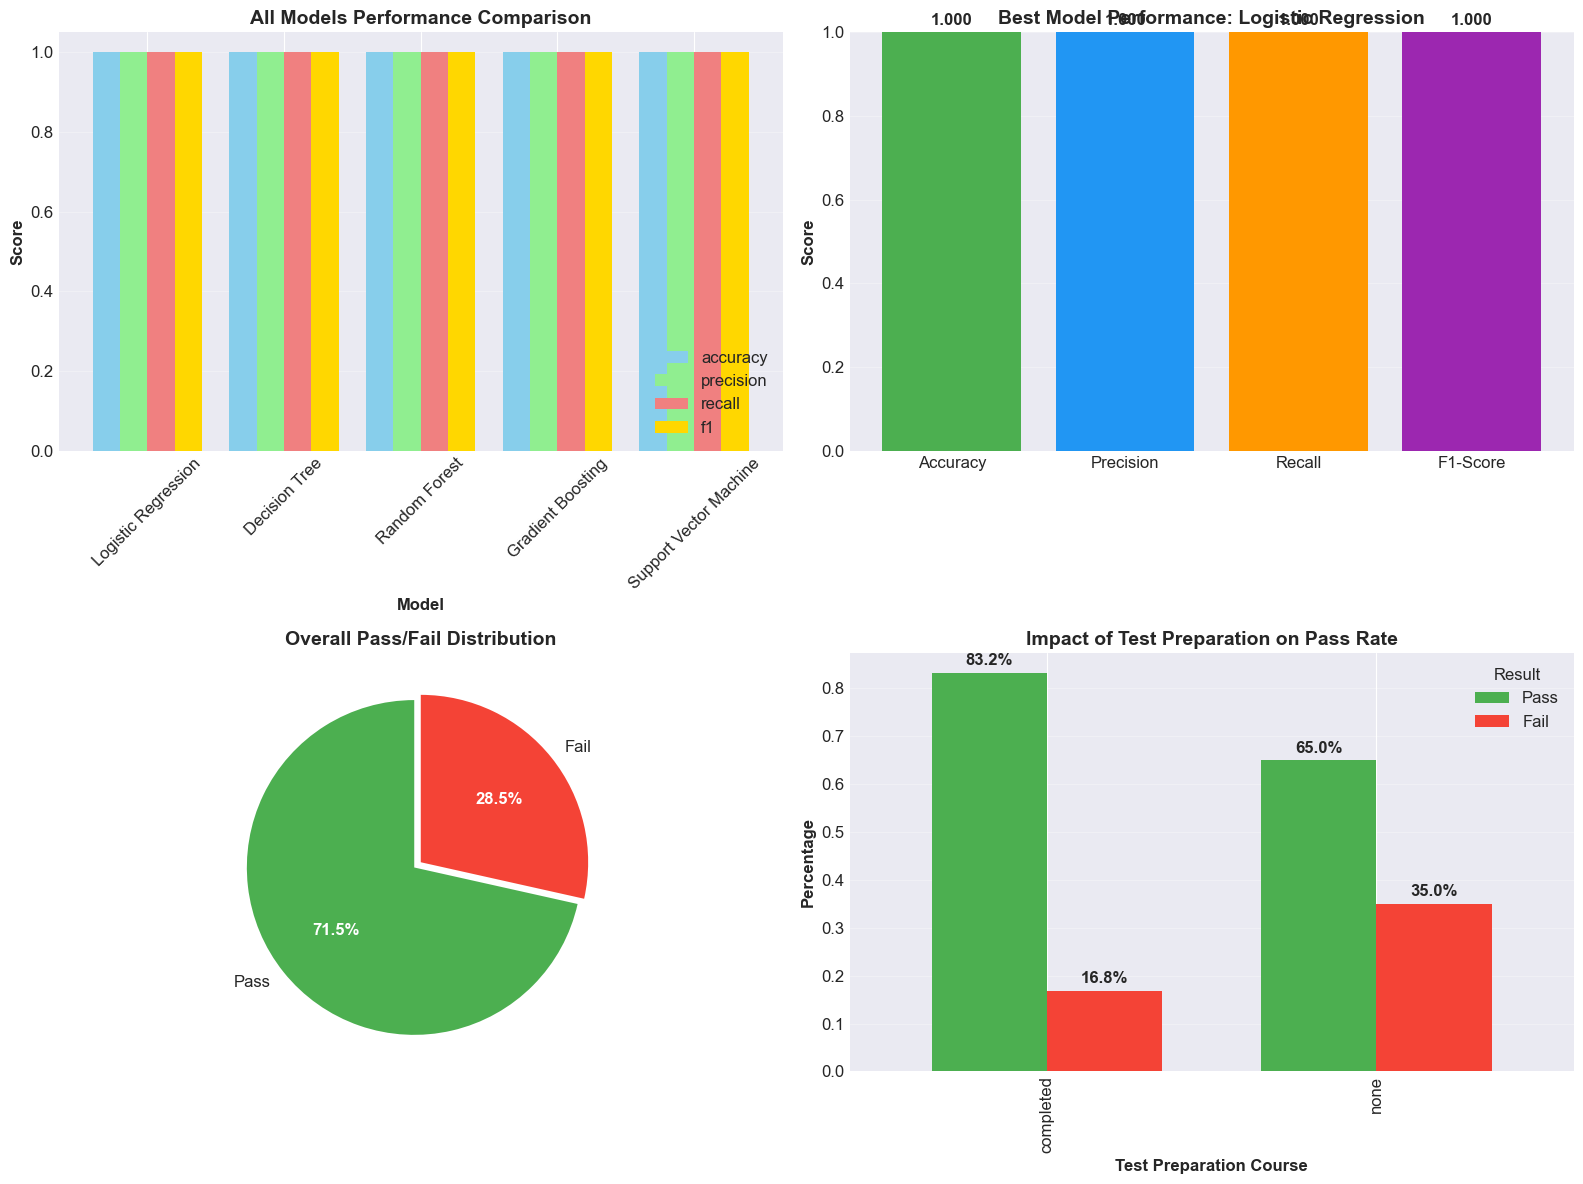


FINAL STATISTICS:
----------------------------------------
Total Students Analyzed: 1000
Passing Students: 715 (71.5%)
At-Risk Students: 285 (28.5%)
Best Model Selected: Logistic Regression
Model Prediction Accuracy: 100.00%


In [22]:
# Final summary visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Model Performance Comparison
models_summary = pd.DataFrame(test_results).T[['accuracy', 'precision', 'recall', 'f1']]
models_summary.plot(kind='bar', ax=axes[0, 0], width=0.8, 
                    color=['skyblue', 'lightgreen', 'lightcoral', 'gold'])
axes[0, 0].set_title('All Models Performance Comparison', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Model', fontweight='bold')
axes[0, 0].set_ylabel('Score', fontweight='bold')
axes[0, 0].legend(loc='lower right')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(True, alpha=0.3, axis='y')

# 2. Key Metrics for Best Model
best_metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
best_values = [
    best_model_test['accuracy'],
    best_model_test['precision'],
    best_model_test['recall'],
    best_model_test['f1']
]

colors = ['#4CAF50', '#2196F3', '#FF9800', '#9C27B0']
bars = axes[0, 1].bar(best_metrics, best_values, color=colors)
axes[0, 1].set_title(f'Best Model Performance: {best_model_name}', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('Score', fontweight='bold')
axes[0, 1].set_ylim([0, 1])
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Add value labels
for bar, value in zip(bars, best_values):
    height = bar.get_height()
    axes[0, 1].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                   f'{value:.3f}', ha='center', va='bottom', fontweight='bold')

# 3. Pass/Fail Distribution Pie Chart
pass_fail_counts = df['pass_fail'].value_counts()
colors_pie = ['#4CAF50', '#F44336']
wedges, texts, autotexts = axes[1, 0].pie(pass_fail_counts.values, labels=pass_fail_counts.index,
                                          autopct='%1.1f%%', colors=colors_pie,
                                          startangle=90, explode=(0.05, 0))
axes[1, 0].set_title('Overall Pass/Fail Distribution', fontsize=14, fontweight='bold')

# Make autotexts bold
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

# 4. Impact of Test Preparation
test_prep_impact = df.groupby('test preparation course')['pass_fail'].value_counts(normalize=True).unstack()
test_prep_impact[['Pass', 'Fail']].plot(kind='bar', ax=axes[1, 1], 
                                        color=['#4CAF50', '#F44336'], width=0.7)
axes[1, 1].set_title('Impact of Test Preparation on Pass Rate', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Test Preparation Course', fontweight='bold')
axes[1, 1].set_ylabel('Percentage', fontweight='bold')
axes[1, 1].legend(title='Result', loc='upper right')
axes[1, 1].grid(True, alpha=0.3, axis='y')

# Add percentage labels
for container in axes[1, 1].containers:
    for bar in container:
        height = bar.get_height()
        axes[1, 1].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                       f'{height:.1%}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Final statistics
print("\nFINAL STATISTICS:")
print("-" * 40)
print(f"Total Students Analyzed: {len(df)}")
print(f"Passing Students: {(df['pass_fail'] == 'Pass').sum()} ({(df['pass_fail'] == 'Pass').sum()/len(df)*100:.1f}%)")
print(f"At-Risk Students: {(df['pass_fail'] == 'Fail').sum()} ({(df['pass_fail'] == 'Fail').sum()/len(df)*100:.1f}%)")
print(f"Best Model Selected: {best_model_name}")
print(f"Model Prediction Accuracy: {best_model_test['accuracy']*100:.2f}%")

In [23]:
import os

# Create folder  "exports" if not exists
export_folder = "exports"
os.makedirs(export_folder, exist_ok=True)

print("\nExporting results...")

# Save processed dataset
df_processed.to_csv(os.path.join(export_folder, 'processed_student_data.csv'), index=False)
print("✓ Processed dataset saved as 'exports/processed_student_data.csv'")

# Save model predictions
predictions_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_test_pred_best,
    'Math_Score': df.loc[y_test.index, 'math score'],
    'Reading_Score': df.loc[y_test.index, 'reading score'],
    'Writing_Score': df.loc[y_test.index, 'writing score'],
    'Average_Score': df.loc[y_test.index, 'average_score']
})
predictions_df.to_csv(os.path.join(export_folder, 'model_predictions.csv'), index=False)
print("✓ Model predictions saved as 'exports/model_predictions.csv'")

# Save model metrics
metrics_df = pd.DataFrame(test_results).T
metrics_df.to_csv(os.path.join(export_folder, 'model_metrics.csv'))
print("✓ Model metrics saved as 'exports/model_metrics.csv'")

print("\n" + "="*60)
print("ALL FILES EXPORTED SUCCESSFULLY!")
print("="*60)
print("\nFiles created:")
print("1. exports/processed_student_data.csv")
print("2. exports/model_predictions.csv")
print("3. exports/model_metrics.csv")


Exporting results...
✓ Processed dataset saved as 'exports/processed_student_data.csv'
✓ Model predictions saved as 'exports/model_predictions.csv'
✓ Model metrics saved as 'exports/model_metrics.csv'

ALL FILES EXPORTED SUCCESSFULLY!

Files created:
1. exports/processed_student_data.csv
2. exports/model_predictions.csv
3. exports/model_metrics.csv
